In [104]:
from pathlib import Path

import torch
from lightning import Trainer

from scRatio.datamodules.datamodule import AnnDataDataModule
from scRatio.models.flow_matching import ConditionalFlowMatchingWithScore

Data 

In [106]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [107]:
# AnnData path 
path = Path("../../project_folder/data/pbmc68k_oversampled/pbmc68k_0.4.h5ad")
dataloader = AnnDataDataModule(adata_path=path,
                               conditions=["treatment"], 
                               num_features=30,
                               train_batch_size=1024,
                               val_batch_size=0,
                               test_batch_size=0)

dataloader.setup()

train_loader = dataloader.train_dataloader()
batch = next(iter(train_loader))
batch

[tensor([[ 0.6878,  0.2161, -0.4319,  ..., -0.1157,  0.8319,  0.0308],
         [ 0.9826,  0.2027, -0.4868,  ..., -0.1564,  0.5052, -0.1586],
         [ 0.5621, -0.0332, -0.1862,  ...,  0.6461,  0.0800,  0.0617],
         ...,
         [-0.3306,  0.0074,  0.2638,  ..., -0.0446,  0.0651,  0.8054],
         [-0.1687,  0.0127, -0.1894,  ..., -0.0787, -0.0763,  0.0273],
         [-1.6971, -0.4955, -0.5053,  ..., -0.0834, -0.0792,  0.0654]]),
 tensor([[0., 1.],
         [0., 1.],
         [1., 0.],
         ...,
         [1., 0.],
         [0., 1.],
         [0., 1.]])]

Model

In [108]:
# Initialize model 
sigma = 0
sigma_min = 0.5
lambda_t = lambda t: torch.sqrt((1 - (1 - sigma_min) * t) ** 2 + sigma * t * (1 - t))
lambda_sp_t = lambda t: (sigma * (1 - 2 * t) - 2 * (1 - sigma_min) * (1 - (1 - sigma_min) * t)) / 2

model = ConditionalFlowMatchingWithScore(input_dim=30,
                                         cond_dims=[2],
                                         hidden_dims=[1024, 1024, 1024],
                                         encoder_hidden_dims=[256],
                                         encoder_out_dim=256,
                                         encoder_out_dim_cond=50, 
                                         time_feature_dim=50, 
                                         lambda_t=lambda_t,
                                         lambda_sp_t=lambda_sp_t,
                                         betas=[0],
                                         lr = 1e-4,
                                         dropout = 0).to(device)

optimizer = model.configure_optimizers()

In [109]:
trainer = Trainer(
    max_steps=40_000,
)

trainer.fit(model, datamodule=dataloader)

/home/icb/alessandro.palma/miniconda3/envs/scRatio/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.10 /home/icb/alessandro.palma/miniconda3/envs/scRat ...
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/icb/alessandro.palma/miniconda3/envs/scRatio/lib/python3.10/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /ictstr01/home/icb/alessandro.palma/environment/scFM_density_estimation/notebooks/differential_abundance_analysis/lightning_logs/version_34045150/checkpoints exists and is not empty.
LOCAL_RANK

┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ data_encoder  │ Encoder         │ 73.7 K │ train │     0 │
│ 1 │ cond_encoders │ ModuleList      │ 13.6 K │ train │     0 │
│ 2 │ vf_mlp        │ FlowMatchingMLP │  2.5 M │ train │     0 │
│ 3 │ score_mlp     │ FlowMatchingMLP │  2.5 M │ train │     0 │
└───┴───────────────┴─────────────────┴────────┴───────┴───────┘

Trainable params: 5.1 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 5.1 M                                                                                                
Total estimated model params size (MB): 20                                                                         
Modules in train mode: 37                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/icb/alessandro.palma/miniconda3/envs/scRatio/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py
:106: Total length of `list` across ranks is zero. Please make sure this was your intention.

/home/icb/alessandro.palma/miniconda3/envs/scRatio/lib/python3.10/site-packages/lightning/pytorch/trainer/connector
s/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider 
increasing the value of the `num_workers` argument` to `num_workers=5` in the `DataLoader` to improve performance.

`Trainer.fit` stopped: `max_steps=40000` reached.


## Evaluate ratio in a batched fashion 

In [154]:
from torch.utils.data import DataLoader, TensorDataset

adata = sc.read_h5ad(path)

X = torch.from_numpy(dataloader._get_representation(adata)).float().to(model.device)
C = torch.from_numpy(dataloader._encode_conditions(adata)).float().to(model.device)
model = model.to(device)
control = torch.tensor([1., 0.]).to(device)
condition = torch.tensor([0., 1.]).to(device)

# Create dataloader to estimate the ratio 
dataloader_ratio = DataLoader(TensorDataset(X, C), 
                              batch_size=1000, 
                              drop_last=False)

In [155]:
lik_ratios_data = []

with torch.no_grad():
    for batch in tqdm(dataloader_ratio):
        X_batch = batch[0]
        C_batch = batch[1]
        ratios = model.estimate_log_density_ratio(data_samples=X_batch, 
                                                  control=control.unsqueeze(0).repeat(X_batch.shape[0], 1), 
                                                  condition=condition.unsqueeze(0).repeat(X_batch.shape[0], 1), 
                                                  point=C_batch, 
                                                  n_steps=2)
        lik_ratios_data.append(ratios)

  0%|          | 0/66 [00:00<?, ?it/s]

In [156]:
lik_ratios_data = np.concatenate(lik_ratios_data)

# Add ratio to AnnData and visualize

In [157]:
adata = sc.read_h5ad(path)

In [158]:
adata.obs["log_ratios"] = lik_ratios_data

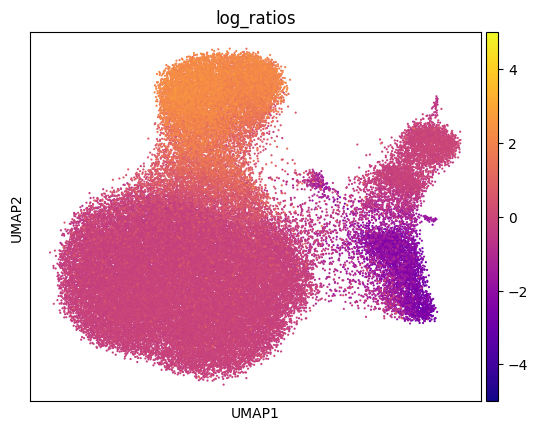

In [159]:
sc.pl.umap(adata, color="log_ratios", s=10, cmap="plasma", vmin=-5, vmax=5)